<a href="https://colab.research.google.com/github/tradingwithme/Works-w-ML-and-w-o-ML/blob/main/Molecular_Generation_from_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
yanmaksi_big_molecules_smiles_dataset_path = kagglehub.dataset_download('yanmaksi/big-molecules-smiles-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'big-molecules-smiles-dataset' dataset.
Data source import complete.


In [ ]:
!rm -r sample_data

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/kaggle/input/big-molecules-smiles-dataset/SMILES_Big_Data_Set.csv")
df.head(5)

,SMILES,pIC50,mol,num_atoms,logP
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,<rdkit.Chem.rdchem.Mol object at 0x7f59df45bc30>,25,4.1591
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c9e0>,36,3.6743
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cac0>,23,1.5361
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cba0>,22,0.9510
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c7b0>,21,3.2130


In [ ]:
df.to_csv('df.csv', index=False)

In [ ]:
import os
import sys

# Uninstall conflicting protobuf and tensorflow
!pip uninstall -y protobuf tensorflow --quiet

# Reinstall tensorflow first to get a compatible protobuf version
!pip install -q tensorflow==2.15.0 # Or a version known to be stable

# Reinstall protobuf
!pip install -q protobuf

# Reinstall molecule-generation
!pip install molecule-generation --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 107.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.chdir('/content')

In [ ]:
!rm -r -f sample_data rl_graph_generation gcpn_dataset.csv

In [ ]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 15.5 MB/s eta 0:00:00


In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()
!conda install -y -c conda-forge rdkit

✨🍰✨ Everything looks OK!
Channels:
 - conda-forge
Platform: linux-64
Solving environment: \ | / - \ | done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [ ]:
import os
os.environ['MPLBACKEND'] = 'Agg'  # valid headless backend

In [ ]:
df = pd.read_csv("df.csv").dropna(subset=["SMILES"])
smiles = df["SMILES"].tolist()

# Write train, valid, test splits
with open("train.smiles", "w") as f:
    f.write("\n".join(smiles))

# Optionally create valid/test splits with smaller subsets
with open("valid.smiles", "w") as f:
    f.write("\n".join(smiles[:500]))  # e.g., first 500

with open("test.smiles", "w") as f:
    f.write("\n".join(smiles[500:1000]))  # next 500

In [ ]:
!molecule_generation preprocess . moler_data moler_traces
!molecule_generation train MoLeR moler_traces

In [ ]:
# Generate 10 molecules using the trained MoLeR model
!molecule_generation sample outputs/ 10 > generated_smiles.csv

2025-12-24 20:05:31.319818: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-24 20:05:31.424982: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-24 20:05:31.425068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-24 20:05:31.427408: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-24 20:05:31.441140: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-24 20:05:31.441559: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [ ]:
import pandas as pd

# Load the generated SMILES strings into a DataFrame
generated_df = pd.read_csv('generated_smiles.csv')

# Display the generated molecules
display(generated_df)

,Loading a trained model from: outputs/GNN_Edge_MLP_MoLeR__2025-12-24_18-19-40_best.pkl
0,CN1C(C2=CC=C(O2)C2=CC=C(O2)C2=CC=C(O2)C2=CC=C(...
1,CC(C)C1=CC(=NN1)C1=CC=C(O1)C1=COC(=C1)C1=COC(=...
2,CN1CC12CCC2C1=CC=C(O1)C1=CC=C(O1)C1=CC=C(O1)C1...
3,C1=COC(=C1)C1=COC(=C1)C1=COC(=C1)C1=COC(=C1)C1...
4,CC12CC3(CCC3C3(CCC3)C(=O)N1NC(=O)C1=CC=C(O1)C1...
5,O=C(O)NCC12CCC3CCCC3C1CCC1=C(CC=C(C3=CC=C(O3)C...
6,C1=COC(C2=COC(C3=COC(C4=COC(C5=COC(C6=COC(C7=C...
7,O=S1(=O)C2NCCCC21C12CCC3CCCC3C1CCC1=C(CC=C(C3=...
8,C1=COC(C2=COC(C3=COC(C4=COC(C5=COC(C6=COC(C7=C...
9,C1=COC(=C1)C1=COC(=C1)C1=COC(=C1)C1=COC(=C1)C1...


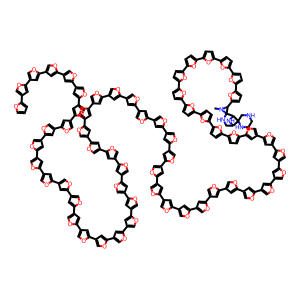

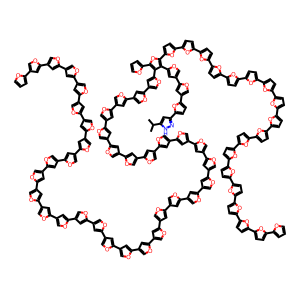

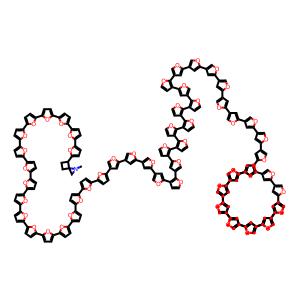

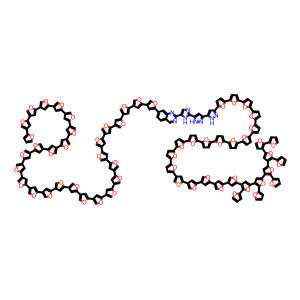

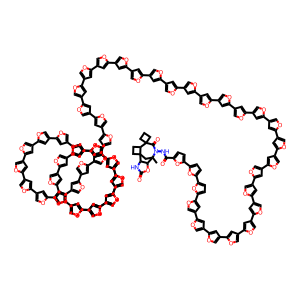

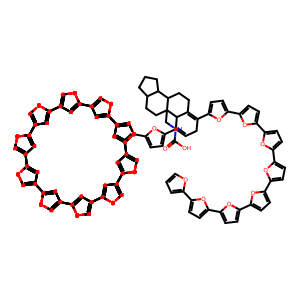

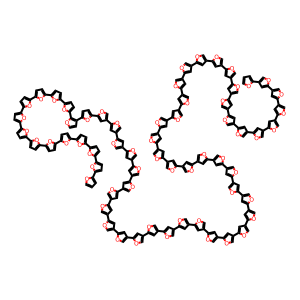

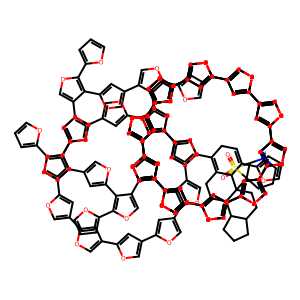

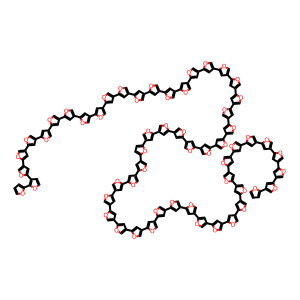

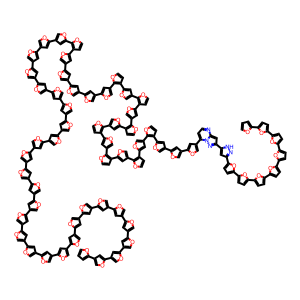

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

for x in pd.read_csv('generated_smiles.csv').iloc[:,0]:
  mol = Chem.MolFromSmiles(x)
  if mol is not None: # Ensure the SMILES string is valid
    display(Draw.MolToImage(mol))
  else:
    print(f"Could not parse SMILES: {x}")